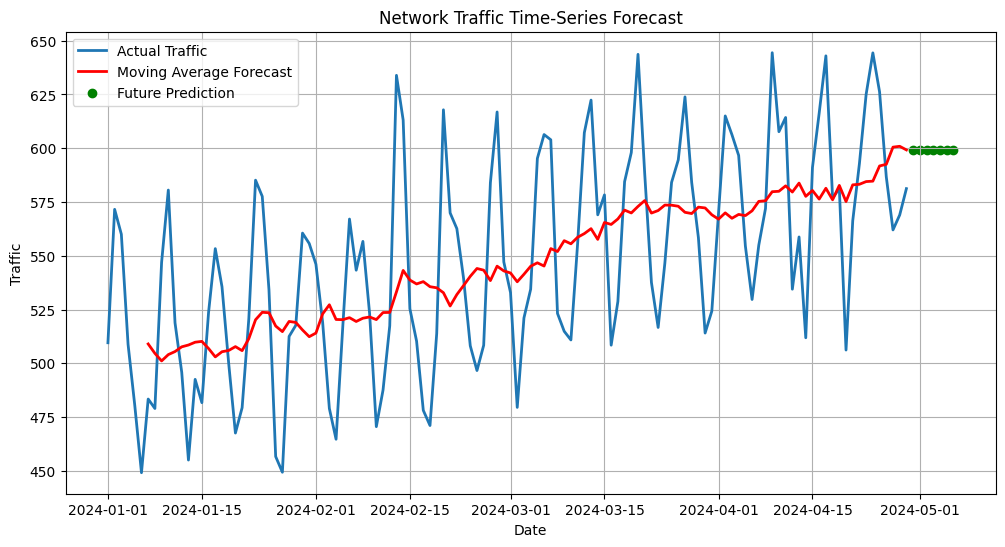

Predicted Traffic for Next 7 Days:
2024-04-30 : 599.24
2024-05-01 : 599.24
2024-05-02 : 599.24
2024-05-03 : 599.24
2024-05-04 : 599.24
2024-05-05 : 599.24
2024-05-06 : 599.24

✓ Normal Network Traffic


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate historical traffic
dates = pd.date_range(start="2024-01-01", periods=120, freq="D")

traffic = (
    500
    + np.linspace(0, 100, 120)
    + 50 * np.sin(np.arange(120) * 2 * np.pi / 7)
    + np.random.normal(0, 20, 120)
)

data = pd.DataFrame({
    "Date": dates,
    "Traffic": traffic
})

# Set Date as index
data.set_index("Date", inplace=True)

# Moving Average Forecast
window = 7
data["Forecast"] = data["Traffic"].rolling(window=window).mean()

# Predict next 7 days
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

future_forecast = [data["Forecast"].iloc[-1]] * 7

# Plot actual and forecast
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Traffic"],
    label="Actual Traffic",
    linewidth=2
)

plt.plot(
    data.index,
    data["Forecast"],
    label="Moving Average Forecast",
    color="red",
    linewidth=2
)

plt.scatter(
    future_dates,
    future_forecast,
    color="green",
    label="Future Prediction"
)

plt.title("Network Traffic Time-Series Forecast")
plt.xlabel("Date")
plt.ylabel("Traffic")
plt.grid(True)
plt.legend()
plt.show()

# Threshold-based DDoS Detection
threshold = 620

print("Predicted Traffic for Next 7 Days:")

for d, t in zip(future_dates, future_forecast):
    print(f"{d.date()} : {t:.2f}")

if future_forecast[0] > threshold:
    print("\n⚠ Potential DDoS Attack Predicted")
else:
    print("\n✓ Normal Network Traffic")